# VLM ADE Analysis Report  
**Comparing baseline performance vs. doScenes prompting variants**  

**Goal:** Evaluate how adding doScenes-style instructions affects model performance, measured by Average Displacement Error (ADE) across scenes. The Vision Language Model (VLM) chosen for our evaluation was OpenEMMA.

**Datasets**
- `vlm_results.csv`: baseline results (no doScenes instructions)
- `vlm_doscenes_results.csv`: multiple prompted runs per scene (with instructions)

## 1. Setup
---


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Load both CSVs
wo_path = "data/vlm_results.csv"
dosc_path = "data/vlm_doscenes_results.csv"

dosc_raw = pd.read_csv(dosc_path)
wo_raw = pd.read_csv(wo_path)

# ----------------------------
# GLOBAL NORMALIZATION
# ----------------------------

# 1. Normalize Baseline (wo)
# Want columns: scene, avgade
wo = wo_raw.copy()
# Handle 'name' vs 'scene'
if "scene" in wo.columns:
    wo_scene_col = "scene"
elif "name" in wo.columns:
    wo_scene_col = "name"
else:
    wo_scene_col = "scene" # fallback

wo[wo_scene_col] = pd.to_numeric(wo[wo_scene_col], errors="coerce")
wo["avgade"] = pd.to_numeric(wo["avgade"], errors="coerce")
wo = wo.dropna(subset=[wo_scene_col, "avgade"])
wo.rename(columns={wo_scene_col: "scene"}, inplace=True)
wo["scene"] = wo["scene"].astype(int)

# 2. Normalize doScenes (dosc)
# Want columns: scene, ade, instruction
dosc = dosc_raw.copy()
dosc["name"] = pd.to_numeric(dosc["name"], errors="coerce")
dosc["ade"]   = pd.to_numeric(dosc["ade"], errors="coerce")
dosc = dosc.dropna(subset=["name", "ade"])
dosc.rename(columns={"name": "scene"}, inplace=True)
dosc["scene"] = dosc["scene"].astype(int)

if "instruction" not in dosc.columns:
    dosc["instruction"] = ""
dosc["instruction"] = dosc["instruction"].astype(str).str.strip()

# 3. Helper for Outliers (Q97.5)
def get_inlier_mask(series):
    """Returns True for values <= 97.5th percentile"""
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return pd.Series([False] * len(series), index=series.index)
    limit = np.percentile(s, 97.5)
    return series <= limit

# Display (matches original output style)
display(dosc.head())
display(wo.head())
print(len(dosc), len(wo))


,test,instruction_type,instruction,scene,ade1s,ade2s,ade3s,ade
0,1,sd,"turn left into the road, Drive around road blo...",1,1.273507,3.306618,4.076085,2.885403
1,1,d,"Turn left, then stay on the right side to avoi...",1,1.028773,2.811420,3.366301,2.402165
2,1,s,Turn right and move to the other lane carefull...,1,0.962500,2.895181,3.486146,2.447942
3,1,s,turn right and then slide into the left lane t...,1,0.957958,2.669760,3.165051,2.264256
4,2,s,turn left at the intersection,2,1.770288,4.183188,5.285939,3.746472


,scene,ade1s,ade2s,ade3s,avgade
0,1,0.901415,2.723886,3.242123,2.289142
1,2,1.724195,4.098373,5.183213,3.668594
2,3,0.476523,0.842209,1.027217,0.781983
3,4,0.654779,4.555891,4.743861,3.318177
4,5,1.049625,2.166530,2.541281,1.919145


1816 849


## 2. Scene-Level Comparison (Baseline vs doScenes Extremes)
---
The doScenes dataset contains **multiple instruction trials per scene**.  
To compare against the baseline (one ADE per scene), we aggregate doScenes by scene into:

- **Best ADE** (minimum): best-performing instruction for the scene  
- **Worst ADE** (maximum): worst-performing instruction for the scene  
- **Average ADE** (mean): average performance across instructions  

We also observe best and worst cases to help interpret *what kinds of prompts help or hurt*.


In [15]:
import pandas as pd
from IPython.display import display, Markdown

# ----------------------------
# 2) Aggregate doScenes once
# ----------------------------
def instr_for_value(g, val):
    vals = g.loc[g["ade"] == val, "instruction"].dropna().astype(str).str.strip().unique()
    return " | ".join([v for v in vals if v])

def agg_one_scene(g):
    best = g["ade"].min()
    worst = g["ade"].max()
    return pd.Series({
        "ade_avg": g["ade"].mean(),
        "ade_best": best,
        "best_instr": instr_for_value(g, best),
        "ade_worst": worst,
        "worst_instr": instr_for_value(g, worst),
    })

# NOTE: make sure `dosc` and `wo` exist in your notebook before running this cell
dosc_agg = dosc.groupby("scene").apply(agg_one_scene).reset_index()

# ----------------------------
# 3) Merge + diffs
# ----------------------------
merged = wo.merge(dosc_agg, on="scene", how="outer").sort_values("scene")

merged["diff_best"]  = (merged["ade_best"]  - merged["avgade"]).abs()
merged["diff_worst"] = (merged["ade_worst"] - merged["avgade"]).abs()

THRESH = 4.0

def make_table(df, mask, cols, new_cols):
    out = df.loc[mask, cols].copy()
    out.columns = new_cols
    return out

table_best = make_table(
    merged,
    merged["diff_best"] >= THRESH,
    ["scene", "avgade", "ade_best", "diff_best"],
    ["Scene", "ADE (wo_doscenes)", "Best ADE (doScenes)", "Difference"],
)

table_worst = make_table(
    merged,
    (merged["ade_worst"] > merged["avgade"]) & (merged["diff_worst"] >= THRESH),
    ["scene", "avgade", "ade_worst", "diff_worst"],
    ["Scene", "ADE (wo_doscenes)", "Worst ADE (doScenes)", "Difference"],
)

mixed_mask = (
    (merged["ade_best"] < merged["avgade"]) &
    (merged["ade_worst"] > merged["avgade"]) &
    (
        ((merged["avgade"] - merged["ade_best"]) >= THRESH) |
        ((merged["ade_worst"] - merged["avgade"]) >= THRESH)
    )
)

table_mixed = make_table(
    merged,
    mixed_mask,
    ["scene", "avgade", "ade_best", "best_instr", "ade_worst", "worst_instr"],
    ["Scene", "ADE (wo_doscenes)", "Best ADE (doScenes)", "Best Instruction(s)",
     "Worst ADE (doScenes)", "Worst Instruction(s)"],
)

pd.set_option("display.float_format", lambda x: f"{x:.6f}")

# ----------------------------
# 4) Display tables
# ----------------------------
display(Markdown(f"### Scenes where BEST doScenes ADE differs by ≥ {THRESH} from wo_doscenes"))
display(table_best if not table_best.empty else pd.DataFrame({"Result": ["None found."]}))

display(Markdown(f"### Scenes where WORST doScenes ADE is ≥ {THRESH} higher (worse) than wo_doscenes"))
display(table_worst if not table_worst.empty else pd.DataFrame({"Result": ["None found."]}))

display(Markdown(f"### EXTREME mixed cases (Best < wo, Worst > wo, and at least one diff ≥ {THRESH}) with instructions"))
display(table_mixed if not table_mixed.empty else pd.DataFrame({"Result": ["None found."]}))


/tmp/ipykernel_1842560/1075387793.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dosc_agg = dosc.groupby("scene").apply(agg_one_scene).reset_index()


### Scenes where BEST doScenes ADE differs by ≥ 4.0 from wo_doscenes

,Scene,ADE (wo_doscenes),Best ADE (doScenes),Difference
83,100,243650.858615,0.000008,243650.858607
91,108,190.683875,2.250403,188.433472
118,157,8.473087,2.097752,6.375336
162,208,499.632793,3.474401,496.158391
434,546,2812421.766340,0.217252,2812421.549088
449,566,8.291919,3.611550,4.680369
488,635,9.961313,0.061465,9.899848
540,689,0.497830,3630.320977,3629.823147
588,760,290.653839,1.269608,289.384232
812,1073,67004.474825,1.912956,67002.561869


### Scenes where WORST doScenes ADE is ≥ 4.0 higher (worse) than wo_doscenes

,Scene,ADE (wo_doscenes),Worst ADE (doScenes),Difference
120,159,2.792096,442.741893,439.949797
121,160,0.262927,69.969197,69.706270
158,203,2.562343,391.477897,388.915554
162,208,499.632793,528.673525,29.040732
286,369,2.885010,7.457136,4.572127
356,443,1.628221,5.860240,4.232019
425,536,2.512077,8.059966,5.547889
430,542,0.403915,20.784498,20.380584
540,689,0.497830,33170.593607,33170.095777
543,697,5.359042,154.955254,149.596212


### EXTREME mixed cases (Best < wo, Worst > wo, and at least one diff ≥ 4.0) with instructions

,Scene,ADE (wo_doscenes),Best ADE (doScenes),Best Instruction(s),Worst ADE (doScenes),Worst Instruction(s)
120,159,2.792096,2.721342,"wait for the pedestrians to cross, then slowly...",442.741893,"Once all individuals cross the crosswalk, proc..."
158,203,2.562343,2.310562,"turn right here, wait for pedestrian to cross ...",391.477897,turn right wait for incoming pedestrian
162,208,499.632793,3.474401,wait until there are no approaching cars and ...,528.673525,Wait for the cars to merge onto the street bef...
286,369,2.885010,2.879925,Make a right turn at the intersection,7.457136,"top in the middle of the intersection, then tu..."
356,443,1.628221,1.195478,drive around the stopped black truck ahead of ...,5.860240,when there are no approaching vehicles drive a...
430,542,0.403915,0.389351,Wait at the intersection if there are cars cro...,20.784498,slowly approach the intersection


## 3. Distribution and Outlier Analysis
---
ADE can contain rare large errors (outliers) that dominate averages.  
To better understand typical behavior, we compare distributions:

- Baseline ADE (no instruction)
- doScenes best / average / worst ADE per scene

,Metric,Mean (All),Mean (Q97.5 Inliers),Mean (Upper Outliers)
0,ADE_NoInstr,6201.442600,2.879300,240316.410200
1,ADE_do_best,9.999300,2.732400,284.461000
2,ADE_do_avg,78.527100,2.929600,2933.786800
3,ADE_do_worst,151.419900,3.110500,5752.954800


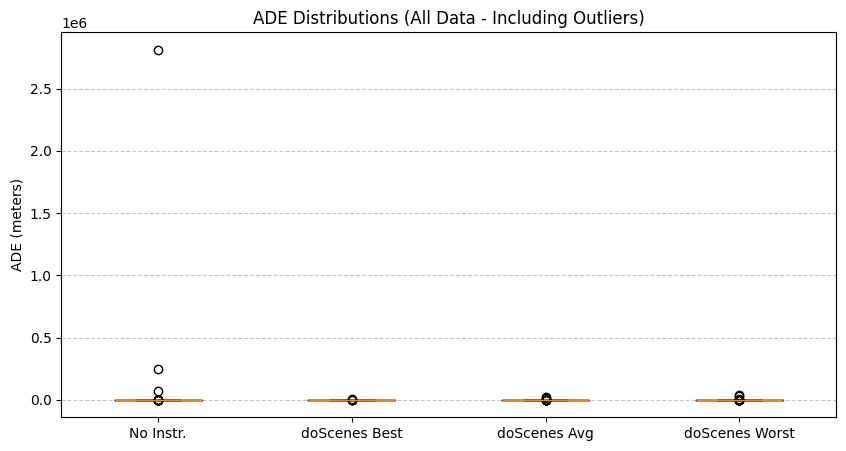

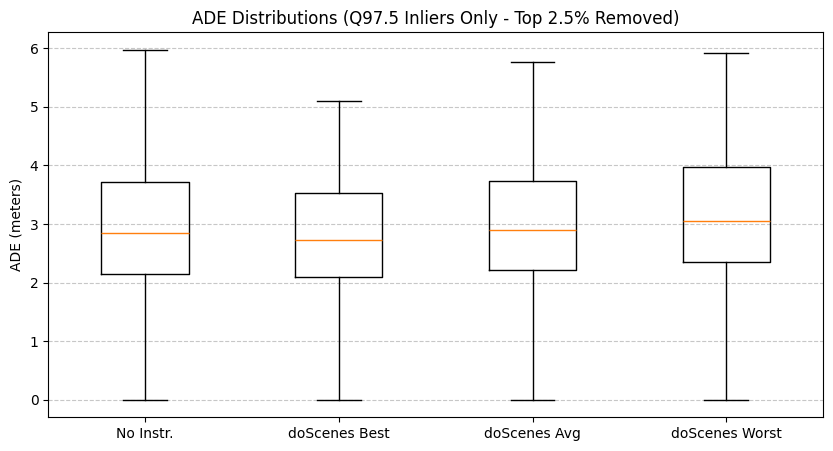

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Aggregate doScenes per scene (re-using dosc/wo from global)
agg = (
    dosc.groupby("scene", as_index=False)
        .agg(
            ade_best=("ade", "min"),
            ade_avg=("ade", "mean"),
            ade_worst=("ade", "max"),
            n_prompts=("ade", "size"),
        )
)

# Merge baseline
merged_dist = pd.merge(wo[["scene", "avgade"]], agg, on="scene", how="inner")

# Long-form
long = pd.DataFrame({
    "ADE_NoInstr":  merged_dist["avgade"],
    "ADE_do_best":  merged_dist["ade_best"],
    "ADE_do_avg":   merged_dist["ade_avg"],
    "ADE_do_worst": merged_dist["ade_worst"],
})

# Outlier flags using your global helper
out_flags = long.apply(lambda col: ~get_inlier_mask(col))

# ----------------------------
# Summary Table (NO counts)
# ----------------------------
rows = []
for col in long.columns:
    s = long[col].dropna().astype(float)
    flags = out_flags[col].reindex(s.index).fillna(False)

    mean_all = s.mean() if len(s) else np.nan
    mean_in  = s[~flags].mean() if (~flags).sum() else np.nan
    mean_out = s[flags].mean() if flags.sum() else np.nan

    rows.append({
        "Metric": col,
        "Mean (All)": mean_all,
        "Mean (Q97.5 Inliers)": mean_in,
        "Mean (Upper Outliers)": mean_out,
    })

summary_df = pd.DataFrame(rows)[
    ["Metric", "Mean (All)", "Mean (Q97.5 Inliers)", "Mean (Upper Outliers)"]
].round(4)

display(summary_df)

# ----------------------------
# Boxplots (FIXED labels arg)
# ----------------------------
pretty_labels = ["No Instr.", "doScenes Best", "doScenes Avg", "doScenes Worst"]
data_all = [long[c].dropna().values for c in long.columns]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data_all, labels=pretty_labels, showfliers=True)   # <- labels= (not tick_labels=)
ax.set_title("ADE Distributions (All Data - Including Outliers)")
ax.set_ylabel("ADE (meters)")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Inliers-only
data_inliers = [long[c][~out_flags[c]].dropna().values for c in long.columns]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data_inliers, labels=pretty_labels, showfliers=False)
ax.set_title("ADE Distributions (Q97.5 Inliers Only - Top 2.5% Removed)")
ax.set_ylabel("ADE (meters)")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


## 4. Instruction Length vs ADE (Word-Count Buckets)
---
Here we test whether **instruction verbosity** correlates with performance.

Steps:
1. Count words in each doScenes instruction
2. Assign it to a bucket (Ultra-Short → Long)
3. Compute ADE means using a trimmed metric (Q97.5 inliers only)
4. Compare doScenes ADE vs baseline ADE on the same set of scenes


In [18]:
# === Word count & buckets ===
def count_words(s: str):
    return len(re.findall(r"[A-Za-z0-9']+", str(s)))

def bucket_label(n):
    if n <= 4:   return "Ultra-Short"
    if n <= 8:   return "Short"
    if n <= 12:  return "Typical"
    if n <= 18:  return "Descriptive"
    return "Long"

word_ranges = {
    "Ultra-Short": "0-4",
    "Short": "5-8",
    "Typical": "9-12",
    "Descriptive": "13-18",
    "Long": "19+",
}

dosc["word_count"] = dosc["instruction"].apply(count_words)
dosc["Bucket"]     = dosc["word_count"].apply(bucket_label)

rows = []
bucket_order = ["Ultra-Short", "Short", "Typical", "Descriptive", "Long"]

for bucket in bucket_order:
    sub = dosc[dosc["Bucket"] == bucket]

    # doScenes ADE (Q97.5 Inliers)
    ade_all = sub["ade"]
    in_do   = get_inlier_mask(ade_all)
    ade_q975 = ade_all[in_do]
    doscenes_mean_q975 = ade_q975.mean() if not ade_q975.empty else np.nan

    # No-Instr baseline (Q97.5)
    scenes = sorted(set(sub["scene"].dropna().astype(int)))
    wo_sub = wo[wo["scene"].isin(scenes)]
    base_all = wo_sub["avgade"]
    in_wo    = get_inlier_mask(base_all)
    base_q975 = base_all[in_wo]
    base_mean_q975 = base_q975.mean() if not base_q975.empty else np.nan

    rows.append({
        "Bucket": bucket,
        "Word Range": word_ranges[bucket],
        "ADE_NoInstr_Q97.5": base_mean_q975,
        "ADE_doScenes_Q97.5": doscenes_mean_q975,
        # removed count columns here
    })

bucket_stats_q975 = pd.DataFrame(rows)
bucket_stats_q975["Bucket"] = pd.Categorical(
    bucket_stats_q975["Bucket"],
    categories=bucket_order,
    ordered=True
)
bucket_stats_q975 = bucket_stats_q975.sort_values("Bucket").reset_index(drop=True)

bucket_stats_q975["Δ_ADE (doScenes - NoInstr)"] = (
    bucket_stats_q975["ADE_doScenes_Q97.5"] - bucket_stats_q975["ADE_NoInstr_Q97.5"]
)

# Display rounded
bucket_stats_q975_display = bucket_stats_q975.copy()
for col in ["ADE_NoInstr_Q97.5", "ADE_doScenes_Q97.5", "Δ_ADE (doScenes - NoInstr)"]:
    bucket_stats_q975_display[col] = bucket_stats_q975_display[col].round(3)

print("ADE by instruction-length bucket (Q97.5 inliers only; drops ONLY the upper 2.5%):\n")
display(bucket_stats_q975_display)


ADE by instruction-length bucket (Q97.5 inliers only; drops ONLY the upper 2.5%):



,Bucket,Word Range,ADE_NoInstr_Q97.5,ADE_doScenes_Q97.5,Δ_ADE (doScenes - NoInstr)
0,Ultra-Short,0-4,3.001000,3.323000,0.321000
1,Short,5-8,3.002000,3.076000,0.074000
2,Typical,9-12,2.916000,2.887000,-0.028000
3,Descriptive,13-18,2.925000,2.902000,-0.023000
4,Long,19+,2.795000,2.784000,-0.011000


## 5. Referentiality Categories vs ADE
---
Some instruction types may include references like:
- **Static**: refers to scene layout or fixed objects
- **Dynamic**: refers to moving agents / trajectories
- **Static + Dynamic**: both
- **None (Non-ref)**: generic instructions

This section compares ADE across these categories using:
- doScenes ADE (Q97.5 inliers)
- Baseline ADE for the same scenes (Q97.5 inliers)
- The difference: (NoInstr − doScenes)


In [19]:
import numpy as np
import pandas as pd

if "instruction_type" not in dosc.columns:
    dosc["instruction_type"] = None

def referentiality_map(it):
    if isinstance(it, str):
        s = it.lower().strip()
        if s in {"sd", "ds"}: return "Static + Dynamic"
        if s == "s":          return "Static Only"
        if s == "d":          return "Dynamic Only"
    return "None (Non-ref)"

dosc["Referentiality"] = dosc.get("instruction_type", pd.Series(index=dosc.index)).apply(referentiality_map)

rows = []
categories = ["None (Non-ref)", "Static Only", "Dynamic Only", "Static + Dynamic"]

for cat in categories:
    sub = dosc[dosc["Referentiality"] == cat].dropna(subset=["ade", "scene"])

    if sub.empty:
        rows.append({
            "Referentiality": cat,
            "ADE_NoInstr_Q97.5": np.nan,
            "ADE_doScenes_Q97.5": np.nan,
            "Δ_ADE (doScenes - NoInstr)": np.nan,
        })
        continue

    # doScenes (Q97.5)
    keep_do = get_inlier_mask(sub["ade"])
    ade_do_q975 = sub.loc[keep_do, "ade"]
    ade_do_mean = ade_do_q975.mean() if not ade_do_q975.empty else np.nan

    # Baseline (Q97.5)
    scenes = sub["scene"].dropna().astype(int).unique()
    base_sub = wo[wo["scene"].isin(scenes)].copy()
    keep_wo = get_inlier_mask(base_sub["avgade"])
    ade_wo_q975 = base_sub.loc[keep_wo, "avgade"]
    ade_wo_mean = ade_wo_q975.mean() if not ade_wo_q975.empty else np.nan

    delta = (ade_do_mean - ade_wo_mean) if (pd.notna(ade_do_mean) and pd.notna(ade_wo_mean)) else np.nan

    rows.append({
        "Referentiality": cat,
        "ADE_NoInstr_Q97.5": round(ade_wo_mean, 3) if pd.notna(ade_wo_mean) else np.nan,
        "ADE_doScenes_Q97.5": round(ade_do_mean, 3) if pd.notna(ade_do_mean) else np.nan,
        "Δ_ADE (doScenes - NoInstr)": round(delta, 3) if pd.notna(delta) else np.nan,
    })

table = pd.DataFrame(rows)
table["Referentiality"] = pd.Categorical(table["Referentiality"], categories=categories, ordered=True)
table = table.sort_values("Referentiality").reset_index(drop=True)

display(table)


,Referentiality,ADE_NoInstr_Q97.5,ADE_doScenes_Q97.5,Δ_ADE (doScenes - NoInstr)
0,None (Non-ref),3.014000,3.397000,0.383000
1,Static Only,3.054000,3.027000,-0.028000
2,Dynamic Only,2.830000,2.764000,-0.065000
3,Static + Dynamic,2.829000,2.783000,-0.045000
